# Implementing TF-IDF

In [ ]:
!pip install fpdf
!pip install PyPDF2
import PyPDF2
from fpdf import FPDF
import math
from collections import Counter


doc1 = """
Artificial intelligence is a branch of computer science that focuses on building smart machines.
These machines are capable of performing tasks that normally require human intelligence.
Examples include speech recognition, decision making, and image classification.

Artificial intelligence is widely used in modern technology.
Companies use artificial intelligence to improve services and automate processes.
AI systems analyze large amounts of data and learn patterns from it.
"""

doc2 = """
Machine learning is a subset of artificial intelligence.
It focuses on algorithms that allow computers to learn from data without explicit programming.

Machine learning models improve their performance as they process more data.
Supervised learning, unsupervised learning, and reinforcement learning are common approaches.
Applications of machine learning include recommendation systems and fraud detection.
"""

doc3 = """
Data science combines statistics, computer science, and domain knowledge.
It aims to extract useful insights from data.

Data scientists analyze datasets, build predictive models, and visualize information.
Data science is used in healthcare, finance, marketing, and many other fields.

With the growth of big data, data science has become one of the most important disciplines in technology.
"""

doc4 = """
Deep learning is a specialized field of machine learning.
It uses neural networks with multiple layers to learn complex patterns in data.

Deep learning models are widely used in computer vision and natural language processing.
They can recognize images, translate languages, and generate text.

Deep learning requires large datasets and powerful hardware such as GPUs to train effectively.
"""


# convert text into pdf
def create_pdf(text, filename):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    for line in text.split("\n"):
      pdf.cell(200,10,txt=line,ln=True)
    pdf.output(filename)

create_pdf(doc1, "doc1.pdf")
create_pdf(doc2, "doc2.pdf")
create_pdf(doc3, "doc3.pdf")
create_pdf(doc4, "doc4.pdf")

def read_pdf(filename):
      text= ""
      with open(filename, "rb") as file:
        reader = PyPDF2.PdfReader(file)

        for page in reader.pages:
          text += page.extract_text()
      return text

pdf_files = ["doc1.pdf", "doc2.pdf", "doc3.pdf", "doc4.pdf"]
documents = []

for file in pdf_files:
  text = read_pdf(file)
  documents.append(text)

print(documents[0])

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=8981d7929ace1b78627cc219051e037dee4a893ad45c8bb8142bbe9177ee9127
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.7 MB/s eta 0:00:00
Artificial intelligence is a branch of computer science that focuses on building smart machines.
These machines are capable of performing tasks that normally require human intelligence.
Examples include speech recognition, decision making, and image classification.
Artificial intelligence is widely used in modern technology.
Companies use artificial intelligence to improve services and automate processes.
AI systems analyze large amounts of data and learn patterns from it.


## Preprocessing

In [ ]:
!pip install nltk

In [ ]:
import nltk
import string
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

preprocessed = []
for i,doc in enumerate(documents):
  #lower case
  doc = doc.lower()
  #tokenize
  tokens = word_tokenize(doc)
  #remove punctuation
  tokens = [token for token in tokens if token not in string.punctuation]
  preprocessed.append(tokens)
  print(f"Document {i+1} - Tokens after preprocessing:")
  print(tokens[:])
  print()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Document 1 - Tokens after preprocessing:
['artificial', 'intelligence', 'is', 'a', 'branch', 'of', 'computer', 'science', 'that', 'focuses', 'on', 'building', 'smart', 'machines', 'these', 'machines', 'are', 'capable', 'of', 'performing', 'tasks', 'that', 'normally', 'require', 'human', 'intelligence', 'examples', 'include', 'speech', 'recognition', 'decision', 'making', 'and', 'image', 'classification', 'artificial', 'intelligence', 'is', 'widely', 'used', 'in', 'modern', 'technology', 'companies', 'use', 'artificial', 'intelligence', 'to', 'improve', 'services', 'and', 'automate', 'processes', 'ai', 'systems', 'analyze', 'large', 'amounts', 'of', 'data', 'and', 'learn', 'patterns', 'from', 'it']

Document 2 - Tokens after preprocessing:
['machine', 'learning', 'is', 'a', 'subset', 'of', 'artificial', 'intelligence', 'it', 'focuses', 'on', 'algorithms', 'that', 'allow', 'computers', 'to', 'learn', 'from', 'data', 'without', 'explicit', 'programming', 'machine', 'learning', 'models', '

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
preprocessed

[['artificial',
  'intelligence',
  'is',
  'a',
  'branch',
  'of',
  'computer',
  'science',
  'that',
  'focuses',
  'on',
  'building',
  'smart',
  'machines',
  'these',
  'machines',
  'are',
  'capable',
  'of',
  'performing',
  'tasks',
  'that',
  'normally',
  'require',
  'human',
  'intelligence',
  'examples',
  'include',
  'speech',
  'recognition',
  'decision',
  'making',
  'and',
  'image',
  'classification',
  'artificial',
  'intelligence',
  'is',
  'widely',
  'used',
  'in',
  'modern',
  'technology',
  'companies',
  'use',
  'artificial',
  'intelligence',
  'to',
  'improve',
  'services',
  'and',
  'automate',
  'processes',
  'ai',
  'systems',
  'analyze',
  'large',
  'amounts',
  'of',
  'data',
  'and',
  'learn',
  'patterns',
  'from',
  'it'],
 ['machine',
  'learning',
  'is',
  'a',
  'subset',
  'of',
  'artificial',
  'intelligence',
  'it',
  'focuses',
  'on',
  'algorithms',
  'that',
  'allow',
  'computers',
  'to',
  'learn',
  'from'

In [ ]:
vocab = set()

for doc in preprocessed:
    vocab.update(doc)#add the vocab from each document to know the unique words we have across the four documents to calculate idf for each unique word we have

vocab = sorted(list(vocab))#the final vocabulary becomes ordered and fixed.

print("Vocabulary size:",len(vocab))


Vocabulary size: 135


In [ ]:
vocab

['a',
 'ai',
 'aims',
 'algorithms',
 'allow',
 'amounts',
 'analyze',
 'and',
 'applications',
 'approaches',
 'are',
 'artificial',
 'as',
 'automate',
 'become',
 'big',
 'branch',
 'build',
 'building',
 'can',
 'capable',
 'classification',
 'combines',
 'common',
 'companies',
 'complex',
 'computer',
 'computers',
 'data',
 'datasets',
 'decision',
 'deep',
 'detection',
 'disciplines',
 'domain',
 'effectively',
 'examples',
 'explicit',
 'extract',
 'field',
 'fields',
 'finance',
 'focuses',
 'fraud',
 'from',
 'generate',
 'gpus',
 'growth',
 'hardware',
 'has',
 'healthcare',
 'human',
 'image',
 'images',
 'important',
 'improve',
 'in',
 'include',
 'information',
 'insights',
 'intelligence',
 'is',
 'it',
 'knowledge',
 'language',
 'languages',
 'large',
 'layers',
 'learn',
 'learning',
 'machine',
 'machines',
 'making',
 'many',
 'marketing',
 'models',
 'modern',
 'more',
 'most',
 'multiple',
 'natural',
 'networks',
 'neural',
 'normally',
 'of',
 'on',
 'one',
 

## 1. TF

We will calculate the tf for each word across each document

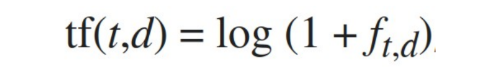




In [ ]:
#contain four list each list show tf for each word in each document
tf = []
#as if i make a dictionary for each document has the word and the corresponding frequency
for doc in preprocessed:
    counts = Counter(doc)
    tf_doc = {}
    for word in vocab:
        f_td = counts[word]
        if f_td > 0:
            tf_doc[word] = math.log(1 + f_td)
        else:
            tf_doc[word] = 0

    tf.append(tf_doc)


In [ ]:
tf

[{'a': 0.6931471805599453,
  'ai': 0.6931471805599453,
  'aims': 0,
  'algorithms': 0,
  'allow': 0,
  'amounts': 0.6931471805599453,
  'analyze': 0.6931471805599453,
  'and': 1.3862943611198906,
  'applications': 0,
  'approaches': 0,
  'are': 0.6931471805599453,
  'artificial': 1.3862943611198906,
  'as': 0,
  'automate': 0.6931471805599453,
  'become': 0,
  'big': 0,
  'branch': 0.6931471805599453,
  'build': 0,
  'building': 0.6931471805599453,
  'can': 0,
  'capable': 0.6931471805599453,
  'classification': 0.6931471805599453,
  'combines': 0,
  'common': 0,
  'companies': 0.6931471805599453,
  'complex': 0,
  'computer': 0.6931471805599453,
  'computers': 0,
  'data': 0.6931471805599453,
  'datasets': 0,
  'decision': 0.6931471805599453,
  'deep': 0,
  'detection': 0,
  'disciplines': 0,
  'domain': 0,
  'effectively': 0,
  'examples': 0.6931471805599453,
  'explicit': 0,
  'extract': 0,
  'field': 0,
  'fields': 0,
  'finance': 0,
  'focuses': 0.6931471805599453,
  'fraud': 0,
 

## 2. IDF
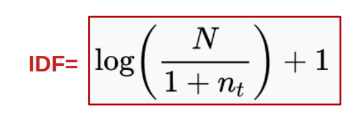

In [ ]:
# N : Number of documents in the corups
N = len(preprocessed)
idf = {}

for word in vocab:
    # n_t : number of documents where the term “t” appears
    n_t = 0
    for doc in preprocessed:
        if word in doc:
            n_t += 1
    idf[word] = math.log(N/(1+n_t)) + 1


## 3. TF-IDF
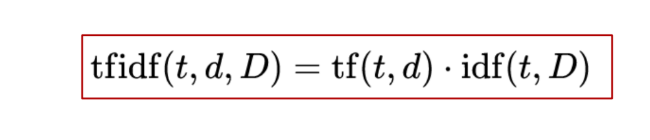

In [ ]:
tfidf = []

for doc_index in range(4):
    tfidf_doc = {}
    for word in vocab:
        tfidf_doc[word] = tf[doc_index][word] * idf[word]

    tfidf.append(tfidf_doc)

## 4. Displaying the words with the heighest TF-IDF

- A high TF-IDF score means that word is a "Signature Word" for that specific document

In [ ]:
for i, doc_tfidf in enumerate(tfidf):
    sorted_words = sorted(doc_tfidf.items(), key=lambda x: x[1], reverse=True)
    print(f"\nDocument {i+1} - Top TF-IDF words:")
    for word, score in sorted_words[:5]:
        print(f"  {word}: {score:.4f}")


Document 1 - Top TF-IDF words:
  intelligence: 2.0724
  machines: 1.8601
  artificial: 1.7851
  that: 1.4147
  ai: 1.1736

Document 2 - Top TF-IDF words:
  learning: 2.5057
  machine: 1.7851
  algorithms: 1.1736
  allow: 1.1736
  applications: 1.1736

Document 3 - Top TF-IDF words:
  science: 2.0724
  the: 1.8601
  data: 1.5117
  aims: 1.1736
  become: 1.1736

Document 4 - Top TF-IDF words:
  deep: 2.3472
  learning: 2.0724
  can: 1.1736
  complex: 1.1736
  effectively: 1.1736


## 5. Creating the embeddings

In [ ]:
embeddings = []
for v in tfidf:
    vector = []
    for word in vocab:
        vector.append(v.get(word, 0))
    embeddings.append(vector)

In [ ]:
for i, vec in enumerate(embeddings):
    print(f"Doc {i+1} embedding:", [round(v,4) for v in vec])


Doc 1 embedding: [0.6931, 1.1736, 0.0, 0.0, 0.0, 1.1736, 0.8926, 1.077, 0.0, 0.0, 0.6931, 1.7851, 0.0, 1.1736, 0.0, 0.0, 1.1736, 0.0, 1.1736, 0.0, 1.1736, 1.1736, 0.0, 0.0, 1.1736, 0.0, 0.6931, 0.0, 0.5385, 0.0, 1.1736, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1736, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8926, 0.0, 0.6931, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1736, 1.1736, 0.0, 0.0, 0.8926, 0.6931, 0.8926, 0.0, 0.0, 2.0724, 0.8535, 0.5385, 0.0, 0.0, 0.0, 0.8926, 0.0, 0.6931, 0.0, 0.0, 1.8601, 1.1736, 0.0, 0.0, 0.0, 1.1736, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1736, 1.077, 0.8926, 0.0, 0.0, 0.8926, 0.0, 1.1736, 0.0, 0.0, 0.0, 1.1736, 0.0, 0.0, 1.1736, 0.0, 0.0, 0.0, 1.1736, 0.0, 0.8926, 0.0, 1.1736, 1.1736, 0.0, 1.1736, 0.0, 0.0, 0.0, 0.0, 0.8926, 1.1736, 0.8926, 0.0, 1.4147, 0.0, 0.0, 1.1736, 0.0, 0.5385, 0.0, 0.0, 0.0, 1.1736, 0.6931, 0.0, 0.0, 0.0, 0.0, 0.8926, 0.0, 0.0]
Doc 2 embedding: [0.6931, 0.0, 0.0, 1.1736, 1.1736, 0.0, 0.0, 0.8535, 1.1736, 1.1736, 0.6931, 0.8926, 0.8926, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 